<div  dir='rtl'><a href="https://zareannpresentation.my.canva.site/"> لینک پرزنت</a> </div>

In [1]:
# !mkdir -p ~/.kaggle
# !cp /content/kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download ninadaithal/imagesoasis
# !unzip -q /content/imagesoasis.zip

In [ ]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, Input
from tensorflow.keras import backend as K
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


In [3]:
IMG_SIZE = (64, 64)
EMBEDDING_DIM = 16
BATCH_SIZE = 128
EPOCHS = 30
LEARNING_RATE = 0.00001
DATASET_PATH = "/content/Data"

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


In [4]:

def load_and_split_data(base_path, test_size=0.2):
    train_dict = {}
    test_dict = {}

    if not os.path.exists(base_path):
        return None, None

    classes = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

    for class_name in classes:
        class_path = os.path.join(base_path, class_name)
        images = []
        for img_name in os.listdir(class_path):
            try:
                img_path = os.path.join(class_path, img_name)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is None: continue
                img = cv2.resize(img, IMG_SIZE)
                img = img.astype('float32') / 255.0
                img = np.expand_dims(img, axis=-1)
                images.append(img)
            except Exception as e:
                pass

        images = np.array(images)


        train_imgs, test_imgs = train_test_split(images, test_size=test_size, random_state=42)
        train_dict[class_name] = train_imgs
        test_dict[class_name] = test_imgs
        print(f"Class '{class_name}': Train={len(train_imgs)}, Test={len(test_imgs)}")


    return train_dict, test_dict
train_data, test_data = load_and_split_data(DATASET_PATH, test_size=0.2)

Class 'Moderate Dementia': Train=390, Test=98
Class 'Mild Dementia': Train=4001, Test=1001
Class 'Non Demented': Train=53777, Test=13445
Class 'Very mild Dementia': Train=10980, Test=2745


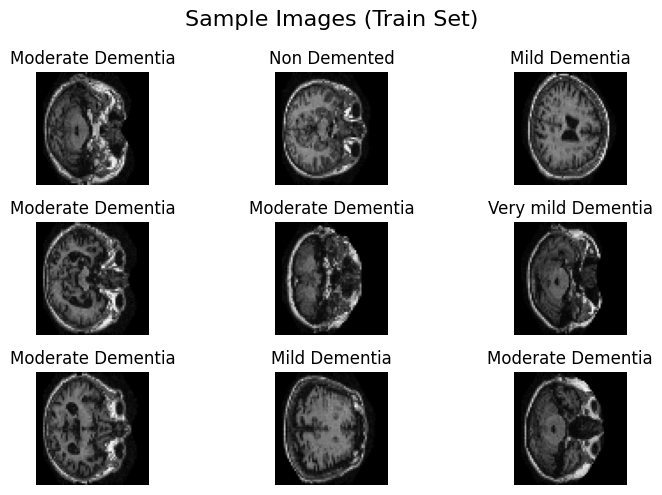

In [ ]:
def visualize_sample_images(data_dict):
    if not data_dict:
        print("No data to visualize.")
        return

    class_names = list(data_dict.keys())
    fig, axes = plt.subplots(3, 3, figsize=(8, 5))
    fig.suptitle('Sample Images (Train Set)', fontsize=16)

    for ax in axes.flat:
        rand_class = random.choice(class_names)
        if len(data_dict[rand_class]) > 0:
            rand_idx = random.randint(0, len(data_dict[rand_class]) - 1)
            img = data_dict[rand_class][rand_idx]

            ax.imshow(img.squeeze(), cmap='gray')
            ax.set_title(rand_class)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

visualize_sample_images(train_data)

In [6]:

class TripletGenerator(tf.keras.utils.Sequence):
    def __init__(self, data_dict, batch_size=128, steps_per_epoch=100):
        self.data_dict = data_dict
        self.class_names = list(data_dict.keys())
        self.batch_size = batch_size
        self.steps = steps_per_epoch

    def __len__(self):
        return self.steps

    def __getitem__(self, index):
        anchors, positives, negatives = [], [], []

        for _ in range(self.batch_size):

            anchor_class = random.choice(self.class_names)
            if len(self.data_dict[anchor_class]) < 2: continue


            negative_class = random.choice([c for c in self.class_names if c != anchor_class])
            if len(self.data_dict[negative_class]) < 1: continue


            idx_a, idx_p = random.sample(range(len(self.data_dict[anchor_class])), 2)
            idx_n = random.randint(0, len(self.data_dict[negative_class]) - 1)

            anchors.append(self.data_dict[anchor_class][idx_a])
            positives.append(self.data_dict[anchor_class][idx_p])
            negatives.append(self.data_dict[negative_class][idx_n])

        X = (
            np.array(anchors, dtype='float32'),
            np.array(positives, dtype='float32'),
            np.array(negatives, dtype='float32')
        )


        y = np.zeros((len(anchors), 1), dtype='float32')

        return X, y
train_generator = TripletGenerator(train_data, batch_size=BATCH_SIZE, steps_per_epoch=50)

In [7]:
def triplet_loss(alpha=0.2):
    def loss(y_true, y_pred):
        anchor = y_pred[:, 0:EMBEDDING_DIM]
        positive = y_pred[:, EMBEDDING_DIM:2*EMBEDDING_DIM]
        negative = y_pred[:, 2*EMBEDDING_DIM:]


        pos_dist = tf.reduce_sum(tf.square(anchor - positive), axis=1)
        neg_dist = tf.reduce_sum(tf.square(anchor - negative), axis=1)

        basic_loss = pos_dist - neg_dist + alpha
        return tf.reduce_mean(tf.maximum(basic_loss, 0.0))
    return loss


def build_embedding_net(input_shape):
    inputs = Input(shape=input_shape)


    x = layers.Conv2D(64, (7, 7), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)

    x = layers.Flatten()(x)
    x = layers.Dense(1024, activation='relu')(x)

    x = layers.Dense(EMBEDDING_DIM, activation=None)(x)
    outputs = layers.Lambda(lambda v: tf.math.l2_normalize(v, axis=1))(x)

    return models.Model(inputs, outputs, name="Encoder")

def build_siamese_model():
    input_shape = (IMG_SIZE[0], IMG_SIZE[1], 1)


    anchor_in = Input(shape=input_shape, name="anchor_in")
    pos_in = Input(shape=input_shape, name="pos_in")
    neg_in = Input(shape=input_shape, name="neg_in")

    encoder = build_embedding_net(input_shape)

    anchor_embed = encoder(anchor_in)
    pos_embed = encoder(pos_in)
    neg_embed = encoder(neg_in)


    merged_vector = layers.Concatenate(axis=1)([anchor_embed, pos_embed, neg_embed])

    model = models.Model(inputs=[anchor_in, pos_in, neg_in], outputs=merged_vector)
    return model, encoder

siamese_model, encoder_model = build_siamese_model()
siamese_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor_in           │ (None, 64, 64, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pos_in (InputLayer) │ (None, 64, 64, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ neg_in (InputLayer) │ (None, 64, 64, 1) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder             │ (None, 16)        │ 33,685,840 │ anchor_in[0][0],  │
│ (Functional)        │                   │            │ pos_in[0][0],     │
│                     │                   │            │ neg_in[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 48)        │          0 │ Encoder[0][0],    │
│ (Concatenate)       │                   │            │ Encoder[1][0],    │
│                     │                   │            │ Encoder[2][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,685,840 (128.50 MB)

 Trainable params: 33,685,840 (128.50 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - loss: 0.1571
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0989
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0828
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0684
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0614
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0548
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - loss: 0.0445
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0411
Epoch 9/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0361
Epoch 10/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0318
Epoch 11/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0297
Epoch 12/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0280
Epoch 13/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 0.0277
Epoch 14/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0239
Epoch 15/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 0.0200
Epoch 16/30
50

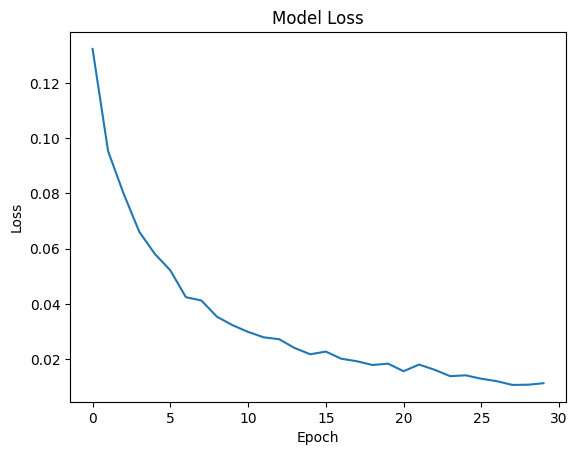

In [8]:
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

siamese_model.compile(loss=triplet_loss(alpha=0.2), optimizer=optimizer)

history = siamese_model.fit(
    train_generator,
    epochs=EPOCHS,
    verbose=1
)


plt.plot(history.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()

In [9]:
X_train_emb, y_train_labels = [], []
X_test_emb, y_test_labels = [], []

for class_name, images in train_data.items():
    if len(images) > 0:
        emb = encoder_model.predict(images, verbose=0)
        X_train_emb.append(emb)
        y_train_labels.extend([class_name] * len(images))


for class_name, images in test_data.items():
    if len(images) > 0:
        emb = encoder_model.predict(images, verbose=0)
        X_test_emb.append(emb)
        y_test_labels.extend([class_name] * len(images))
X_train_emb = np.vstack(X_train_emb)
y_train_labels = np.array(y_train_labels)

X_test_emb = np.vstack(X_test_emb)
y_test_labels = np.array(y_test_labels)
knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean')
knn.fit(X_train_emb, y_train_labels)
y_pred = knn.predict(X_test_emb)
print(classification_report(y_test_labels, y_pred))

                    precision    recall  f1-score   support

     Mild Dementia       1.00      1.00      1.00      1001
 Moderate Dementia       1.00      1.00      1.00        98
      Non Demented       1.00      1.00      1.00     13445
Very mild Dementia       0.98      0.98      0.98      2745

          accuracy                           0.99     17289
         macro avg       0.99      0.99      0.99     17289
      weighted avg       0.99      0.99      0.99     17289

